# PINNs from Scratch — Newton's Law of Cooling

A complete walkthrough of a Physics-Informed Neural Network on the simplest possible
ODE problem, so that every logical step is visible.

**Problem.** A hot object at temperature $T(t)$ cooling in an environment at $T_\text{env}$
follows Newton's law of cooling:
$$\frac{dT}{dt} = -R\,(T - T_\text{env})$$
with closed-form solution
$$T(t) = T_\text{env} + (T_0 - T_\text{env})\,e^{-R t}.$$

We'll generate noisy data from this law, train several models, and compare them:

| Model | What it uses |
|---|---|
| Polynomial regression | Data only, no physics |
| Curve fit (TRF / LM) | Data + *exact* model form |
| Vanilla NN | Data only |
| PINN | Data + ODE residual |
| PINN with parameter discovery | Data + ODE residual, **R** unknown & learned |


## 1. Imports

In [1]:
import functools
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from scipy.optimize import curve_fit

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Output folder for all figures ---
import os
PLOTS_DIR = os.path.join(os.getcwd(), 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f'Saving all figures to: {PLOTS_DIR}')

Saving all figures to: /home/reza/PINNs/experiment/cooling_rate_v2/plots


## 2. Configuration

All knobs in one place. Everything downstream reads from here — nothing hard-coded.

**Notes on choices:**

- `noise_coeff = 2` — standard deviation of Gaussian noise added on top of the true cooling curve.
- `pinn_collocation_points = 1000` — points where we enforce the physics (ODE residual).
  These are *not* labeled data; they are places where we demand the network's derivative
  match the ODE. They can live anywhere in the domain, including regions with no data.
- `pinn_loss_weight` = λ — the weight balancing data loss vs. physics loss.
  Too small: physics is ignored. Too large: the network underfits the data.


In [2]:
# --- Physics of the problem ---
Tenv = 25.0          # environment temperature (°C)
T0   = 100.0         # initial temperature (°C)
R    = 0.005         # true cooling rate (1/s)
duration = 1000      # simulation length (s)

# --- Data sampling ---
number_of_points = 100   # noisy observations
noise_coeff      = 2.0   # std of Gaussian noise (°C)

# --- PINN / Discovery ---
pinn_collocation_points = 1000
pinn_loss_weight        = 1.0   # lambda
discovery_loss_weight   = 1.0

# --- Training ---
vanilla_epochs   = 3000
pinn_epochs      = 3000
discovery_epochs = 4000

# --- Architecture ---
n_hidden_layers = 4
n_units         = 32
learning_rate   = 1e-3
r_learning_rate = 1e-4   # slower LR for the physical parameter (curriculum-style)

# --- Device ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 3. Seeds

Fix randomness for reproducibility. NumPy controls the noise; PyTorch controls weight init
and any random sampling inside the training loop.


In [3]:
np.random.seed(10)
torch.manual_seed(42)
# If running on GPU, also seed CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

## 4. Dataset Generation

We generate two things:

1. A dense **true curve** `(times, temps)` — used only for visualization.
2. **Noisy observations** `(t, T)` — sampled at `number_of_points` locations,
   with Gaussian noise $\mathcal{N}(0, \sigma^2)$ added (where $\sigma$ = `noise_coeff`).

The noise histogram is an important sanity check: if it doesn't look Gaussian,
something is off with the RNG or the noise amplitude.


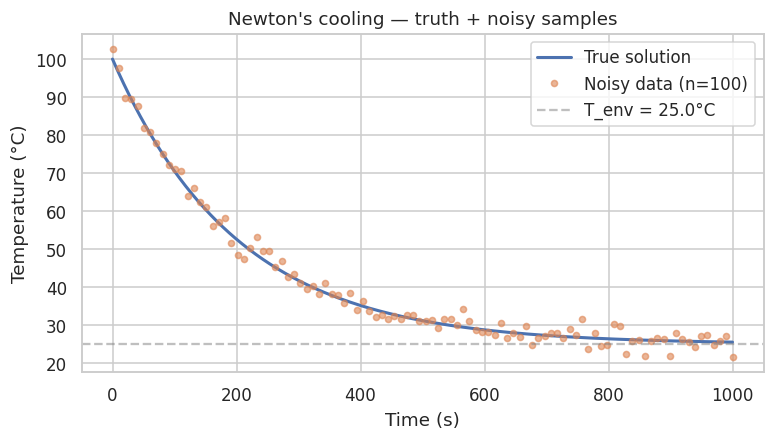

In [4]:
def cooling_law(t, Tenv, T0, R):
    '''Analytical solution of Newton's law of cooling.'''
    return Tenv + (T0 - Tenv) * np.exp(-R * t)

# Dense true curve for plotting (not used for training)
times = np.linspace(0, duration, duration)
temps = cooling_law(times, Tenv=Tenv, T0=T0, R=R)

# Sparse, noisy measurements -- this is what the model actually sees
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
t = np.linspace(0, duration, number_of_points)
T = eq(t) + noise_coeff * np.random.randn(number_of_points)

# --- Plot 1: data vs truth ---
plt.figure(figsize=(8, 4))
plt.plot(times, temps, label='True solution', lw=2)
plt.plot(t, T, 'o', ms=4, alpha=0.6, label=f'Noisy data (n={number_of_points})')
plt.axhline(Tenv, color='grey', ls='--', alpha=0.5, label=f'T_env = {Tenv}°C')
plt.xlabel('Time (s)'); plt.ylabel('Temperature (°C)')
plt.title("Newton's cooling — truth + noisy samples")
plt.legend(); plt.savefig(os.path.join(PLOTS_DIR, '01_data_vs_truth.png'), dpi=150, bbox_inches='tight')
plt.show()

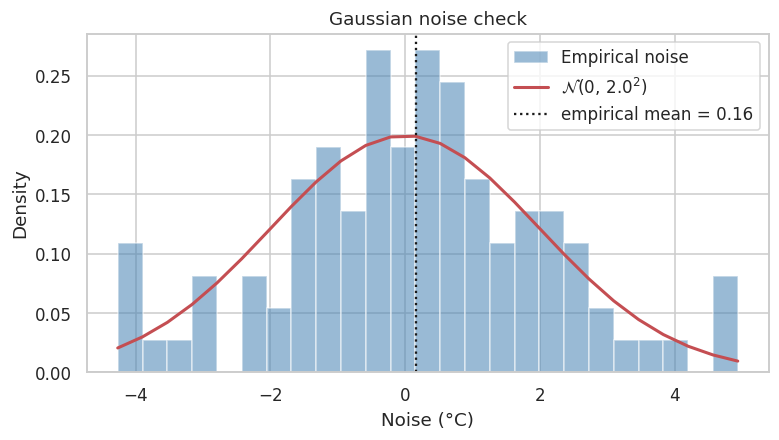

Empirical mean: +0.159   (expected 0)
Empirical std : 1.934   (expected 2.0)


In [5]:
# --- Plot 2: noise histogram vs theoretical Gaussian ---
noise = T - eq(t)

plt.figure(figsize=(8, 4))
count, bins, _ = plt.hist(noise, bins=25, density=True, alpha=0.55,
                           color='steelblue', label='Empirical noise')

mu, sigma = 0.0, noise_coeff
gauss = 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-(bins - mu)**2 / (2*sigma**2))
plt.plot(bins, gauss, 'r-', lw=2, label=f'$\\mathcal{{N}}(0,\\,{sigma}^2)$')

plt.axvline(noise.mean(), color='k', ls=':', label=f'empirical mean = {noise.mean():.2f}')
plt.title('Gaussian noise check')
plt.xlabel('Noise (°C)'); plt.ylabel('Density')
plt.legend(); plt.savefig(os.path.join(PLOTS_DIR, '02_noise_histogram.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Empirical mean: {noise.mean():+.3f}   (expected 0)")
print(f"Empirical std : {noise.std():.3f}   (expected {noise_coeff})")

## 5. Train / Test Split

80 / 20 split. The split is random — points are shuffled before splitting —
so training points are scattered across the domain.


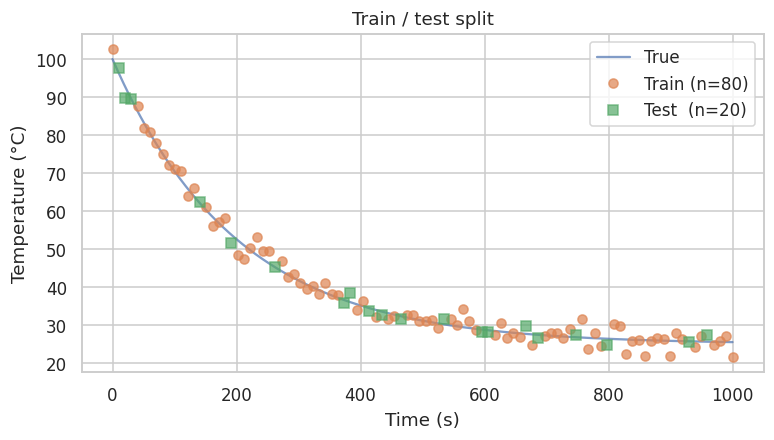

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    t, T, test_size=0.2, random_state=10
)

# reshape to (N, 1) for sklearn / torch
x_train = x_train.reshape(-1, 1); x_test = x_test.reshape(-1, 1)
y_train = y_train.reshape(-1, 1); y_test = y_test.reshape(-1, 1)
times_r = times.reshape(-1, 1);   temps_r = temps.reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.plot(times, temps, label='True', alpha=0.7)
plt.plot(x_train, y_train, 'o', label=f'Train (n={len(x_train)})', alpha=0.7)
plt.plot(x_test,  y_test,  's', label=f'Test  (n={len(x_test)})',  alpha=0.7)
plt.xlabel('Time (s)'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.title('Train / test split'); plt.savefig(os.path.join(PLOTS_DIR, '03_train_test_split.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.1 Standardization

Neural networks train far more reliably when inputs and outputs have mean 0 and std 1.
We use `StandardScaler` fit **on the training set only** (never on test) to avoid
leakage. The same scaler is then applied to test data, to the dense `times` array
(for plotting), and — critically — when we convert back from standardized space to
physical units inside the physics loss.

**Standardization relations** (we'll need these for the PINN chain rule):

$$t_s = \frac{t - \mu_t}{\sigma_t}, \quad T_s = \frac{T - \mu_T}{\sigma_T}$$

so that $t = \sigma_t\, t_s + \mu_t$ and $T = \sigma_T\, T_s + \mu_T$.


  mu_t = 509.343   sigma_t = 292.654
  mu_T = 39.634   sigma_T = 17.980


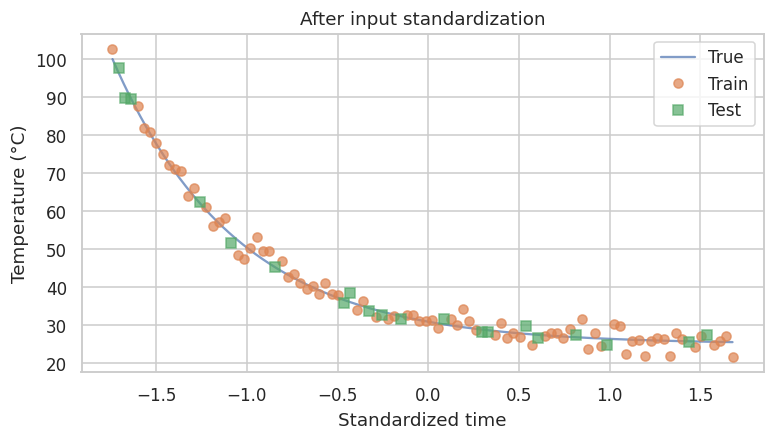

In [7]:
x_scaler = StandardScaler().fit(x_train)
y_scaler = StandardScaler().fit(y_train)

x_train_s = x_scaler.transform(x_train)
x_test_s  = x_scaler.transform(x_test)
times_s   = x_scaler.transform(times_r)

y_train_s = y_scaler.transform(y_train)
y_test_s  = y_scaler.transform(y_test)

# Save scaling constants explicitly -- the physics loss will need them
mu_t, sigma_t = float(x_scaler.mean_[0]), float(x_scaler.scale_[0])
mu_T, sigma_T = float(y_scaler.mean_[0]), float(y_scaler.scale_[0])

print(f"  mu_t = {mu_t:.3f}   sigma_t = {sigma_t:.3f}")
print(f"  mu_T = {mu_T:.3f}   sigma_T = {sigma_T:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(times_s, temps, label='True', alpha=0.7)
plt.plot(x_train_s, y_train, 'o', label='Train', alpha=0.7)
plt.plot(x_test_s,  y_test,  's', label='Test',  alpha=0.7)
plt.xlabel('Standardized time'); plt.ylabel('Temperature (°C)')
plt.title('After input standardization')
plt.legend(); plt.savefig(os.path.join(PLOTS_DIR, '04_standardized.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Architectures

### 6.1 Why `tanh` instead of `ReLU`?

PINNs compute derivatives of the network's output via **autograd**.
For first-order ODEs like Newton's cooling we need only $dT/dt$, so ReLU would
technically work. But:

- ReLU is piecewise linear, so its **second derivative is zero almost everywhere** —
  if you ever extend to a 2nd-order PDE (e.g. heat equation, Burgers), the physics
  residual becomes uninformative.
- `tanh` is smooth and infinitely differentiable, so higher-order derivatives
  remain meaningful. It is the de-facto standard activation in the PINN literature.

### 6.2 Two classes

- **`MLP`** — a plain fully-connected network. Used for both the vanilla baseline
  *and* as the backbone of the PINN.
- **`DiscoveryNet`** — subclass of MLP with an extra trainable scalar `self.r`.
  This is the unknown physical parameter we recover in the inverse problem.


In [8]:
class MLP(nn.Module):
    '''Fully-connected tanh MLP for PINN-style problems.'''
    def __init__(self, input_dim=1, output_dim=1,
                 n_units=n_units, n_hidden=n_hidden_layers):
        super().__init__()
        layers = [nn.Linear(input_dim, n_units), nn.Tanh()]
        for _ in range(n_hidden - 1):
            layers += [nn.Linear(n_units, n_units), nn.Tanh()]
        layers += [nn.Linear(n_units, output_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DiscoveryNet(MLP):
    '''MLP + a single trainable physical parameter r (the unknown cooling rate).'''
    def __init__(self, r_init=0.0, **kw):
        super().__init__(**kw)
        # nn.Parameter => shows up in .parameters() and gets optimised by Adam
        self.r = nn.Parameter(torch.tensor([r_init], dtype=torch.float32))


def grad(outputs, inputs):
    '''dy/dx via autograd. create_graph=True so we could take second derivatives.'''
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
    )[0]


def to_tensor(x, requires_grad=False):
    t = torch.tensor(x, dtype=torch.float32, device=DEVICE)
    if requires_grad: t.requires_grad_(True)
    return t

# Sanity: how many parameters?
tmp = MLP()
n_params = sum(p.numel() for p in tmp.parameters())
print(f'MLP parameters: {n_params}')

MLP parameters: 3265


## 7. Collocation Points

Collocation points are where we **enforce the ODE**. They are *not* labeled data —
no target temperature is attached to them. At each collocation point $t_c$ we simply
demand
$$\frac{dT_\text{net}}{dt}\bigg|_{t_c} + R\,(T_\text{net}(t_c) - T_\text{env}) \approx 0.$$

This is a purely **self-referential constraint**: the network's output has to be
consistent with *its own* derivative according to the ODE. That is the whole trick.

**Where to place them?** We cover the full time domain uniformly. They can be placed
in regions with *no* training data — that's precisely where the physics prior helps most.


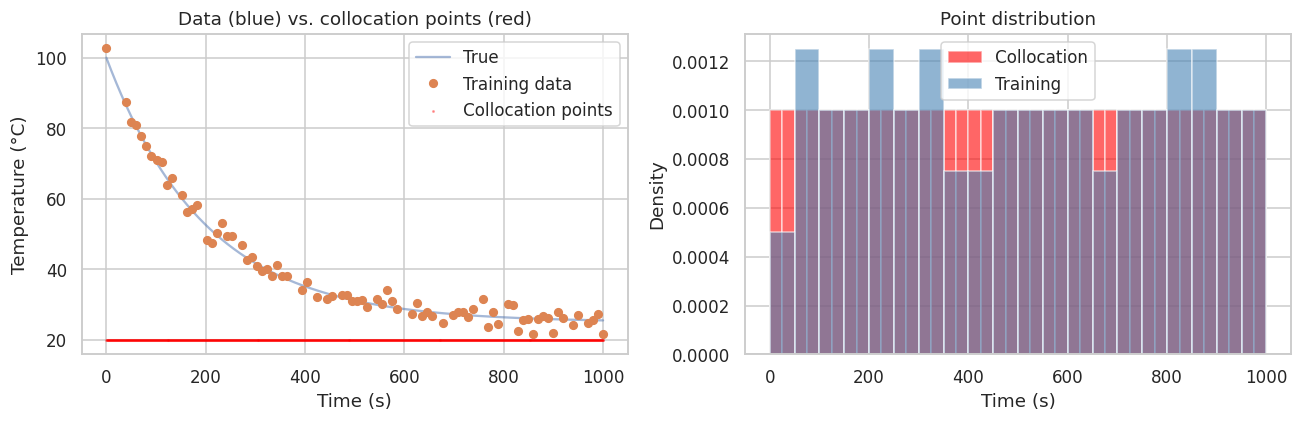

Collocation points: 1000
Training points  : 80


In [9]:
# Collocation points in original time units, then standardized (same as training data)
t_phys_original = np.linspace(0, duration, pinn_collocation_points).reshape(-1, 1)
t_phys_s = x_scaler.transform(t_phys_original)
t_phys_tensor = to_tensor(t_phys_s, requires_grad=True)

# Visualize: where are training points vs. collocation points?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(times, temps, label='True', alpha=0.5)
axes[0].plot(x_train, y_train, 'o', label='Training data', ms=5)
axes[0].scatter(t_phys_original, np.full_like(t_phys_original, Tenv - 5),
                s=1, color='red', alpha=0.3, label='Collocation points')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Data (blue) vs. collocation points (red)')
axes[0].legend()

axes[1].hist(t_phys_original, bins=40, alpha=0.6, color='red',
             label='Collocation', density=True)
axes[1].hist(x_train.ravel(), bins=20, alpha=0.6, color='steelblue',
             label='Training', density=True)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Density')
axes[1].set_title('Point distribution')
axes[1].legend()

plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '05_collocation_points.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Collocation points: {pinn_collocation_points}')
print(f'Training points  : {len(x_train)}')

## 8. Physics Loss — The Core of a PINN

### The ODE in physical units

$$\frac{dT}{dt} = -R\,(T - T_\text{env})$$

### The ODE in standardized units

The network operates in standardized $(t_s, T_s)$ space. We need to compute the
residual there. Using the chain rule on $t = \sigma_t t_s + \mu_t$,
$T = \sigma_T T_s + \mu_T$:

$$\frac{dT}{dt} = \frac{dT}{dT_s}\cdot\frac{dT_s}{dt_s}\cdot\frac{dt_s}{dt}
= \sigma_T \cdot \frac{dT_s}{dt_s} \cdot \frac{1}{\sigma_t}
= \frac{\sigma_T}{\sigma_t}\cdot\frac{dT_s}{dt_s}.$$

Autograd gives us $dT_s/dt_s$. We rescale it to physical units, rescale $T_s$ to °C,
and form the residual in physical units. Mean-square of the residual over all
collocation points is the **physics loss**.

### Total loss

$$\mathcal{L} = \underbrace{\frac{1}{N_\text{data}}\sum_i (T_\text{net}(t_i) - T_i)^2}_\text{data loss (MSE)}
\; + \; \lambda \cdot
\underbrace{\frac{1}{N_\text{phys}}\sum_c \left(\frac{dT_\text{net}}{dt}\Big|_{t_c} + R(T_\text{net}(t_c) - T_\text{env})\right)^2}_\text{physics loss}$$


In [10]:
def physics_loss(model, t_phys=t_phys_tensor, R_value=R):
    '''Compute the mean-square ODE residual at collocation points.

    Model operates in standardized (t_s, T_s) space. We convert back to
    physical units before evaluating the ODE.
    '''
    Ts = model(t_phys)              # standardized temperature
    dTs_dts = grad(Ts, t_phys)      # dT_s / dt_s

    # Back to physical units
    T_celsius = Ts * sigma_T + mu_T
    dT_dt     = dTs_dts * (sigma_T / sigma_t)

    residual = dT_dt + R_value * (T_celsius - Tenv)
    return torch.mean(residual ** 2)

## 9. Training

Three networks trained in sequence:

1. **Vanilla NN** — data loss only.
2. **PINN** — data loss + physics loss, with the *true* R.
3. **Discovery PINN** — data loss + physics loss, with R as an *unknown trainable parameter*.
   Curriculum warmup: data loss only for the first stretch, then physics kicks in.
   A separate (smaller) learning rate for `r` per standard practice for inverse PINNs.


In [11]:
# Tensors used by all training loops
xtr_t = to_tensor(x_train_s)
ytr_t = to_tensor(y_train_s)
xte_t = to_tensor(x_test_s)
yte_t = to_tensor(y_test_s)

loss_fn = nn.MSELoss()

### 9.1 Vanilla NN

In [12]:
torch.manual_seed(42)
net_vanilla = MLP().to(DEVICE)
opt_v = optim.Adam(net_vanilla.parameters(), lr=learning_rate)

train_losses_v, test_losses_v = [], []

for ep in range(vanilla_epochs):
    opt_v.zero_grad()
    pred = net_vanilla(xtr_t)
    loss = loss_fn(pred, ytr_t)
    loss.backward(); opt_v.step()

    train_losses_v.append(loss.item())
    with torch.no_grad():
        test_losses_v.append(loss_fn(net_vanilla(xte_t), yte_t).item())

    if ep % (vanilla_epochs // 10) == 0:
        print(f'  ep {ep:4d}/{vanilla_epochs} | train {train_losses_v[-1]:.4e} '
              f'| test {test_losses_v[-1]:.4e}')

print(f'  final train loss: {train_losses_v[-1]:.4e}')

  ep    0/3000 | train 9.8022e-01 | test 1.5924e+00


  ep  300/3000 | train 1.4723e-02 | test 7.9867e-03


  ep  600/3000 | train 1.2645e-02 | test 8.3892e-03


  ep  900/3000 | train 1.2415e-02 | test 9.1947e-03


  ep 1200/3000 | train 1.2383e-02 | test 9.4103e-03


...

  ep 1800/3000 | train 1.2357e-02 | test 9.1260e-03


  ep 2100/3000 | train 1.2349e-02 | test 9.0233e-03


  ep 2400/3000 | train 1.2341e-02 | test 8.9275e-03


  ep 2700/3000 | train 1.2332e-02 | test 8.8315e-03


  final train loss: 1.2321e-02


### 9.2 PINN (known R)

In [13]:
torch.manual_seed(42)
net_pinn = MLP().to(DEVICE)
opt_p = optim.Adam(net_pinn.parameters(), lr=learning_rate)

train_data_losses_p, train_phys_losses_p, train_total_p, test_losses_p = [], [], [], []

for ep in range(pinn_epochs):
    opt_p.zero_grad()
    pred = net_pinn(xtr_t)
    l_data = loss_fn(pred, ytr_t)
    l_phys = physics_loss(net_pinn)
    loss = l_data + pinn_loss_weight * l_phys
    loss.backward(); opt_p.step()

    train_data_losses_p.append(l_data.item())
    train_phys_losses_p.append(l_phys.item())
    train_total_p.append(loss.item())
    with torch.no_grad():
        test_losses_p.append(loss_fn(net_pinn(xte_t), yte_t).item())

    if ep % (pinn_epochs // 10) == 0:
        print(f'  ep {ep:4d}/{pinn_epochs} | data {l_data.item():.4e} '
              f'| phys {l_phys.item():.4e} | test {test_losses_p[-1]:.4e}')

print(f'  final data loss: {train_data_losses_p[-1]:.4e}  '
      f'physics loss: {train_phys_losses_p[-1]:.4e}')

  ep    0/3000 | data 9.8022e-01 | phys 3.2217e-03 | test 1.5924e+00


  ep  300/3000 | data 1.4253e-02 | phys 4.9092e-04 | test 7.5426e-03


  ep  600/3000 | data 1.2582e-02 | phys 6.8062e-05 | test 8.4321e-03


  ep  900/3000 | data 1.2405e-02 | phys 5.2331e-05 | test 8.9409e-03


  ep 1200/3000 | data 1.2381e-02 | phys 5.2129e-05 | test 8.7744e-03


...

  ep 1800/3000 | data 1.2425e-02 | phys 4.8502e-05 | test 8.8476e-03


  ep 2100/3000 | data 1.2395e-02 | phys 4.6703e-05 | test 8.6183e-03


  ep 2400/3000 | data 1.2425e-02 | phys 4.8564e-05 | test 8.7965e-03


  ep 2700/3000 | data 1.2403e-02 | phys 4.4344e-05 | test 8.2157e-03


  final data loss: 1.2367e-02  physics loss: 4.6346e-05


### 9.3 Parameter discovery (inverse problem)

Two tricks from the PINN-for-inverse-problems playbook:

1. **Curriculum warmup** — let the network fit the data first (first 500 epochs).
   If we turn physics on immediately while `r ≈ 0`, the physics loss pulls the
   network toward the wrong solution.
2. **Separate learning rates** — the physical parameter `r` gets a smaller LR
   than the network weights, so it moves smoothly and doesn't overshoot.


In [14]:
torch.manual_seed(42)
net_disc = DiscoveryNet(r_init=0.0).to(DEVICE)

# Separate parameter groups with different learning rates
network_params = [p for n, p in net_disc.named_parameters() if n != 'r']
opt_d = optim.Adam([
    {'params': network_params, 'lr': learning_rate},
    {'params': [net_disc.r],   'lr': r_learning_rate},
])

warmup_epochs = 500
train_data_losses_d, train_phys_losses_d, r_history = [], [], []

for ep in range(discovery_epochs):
    opt_d.zero_grad()
    pred = net_disc(xtr_t)
    l_data = loss_fn(pred, ytr_t)

    if ep < warmup_epochs:
        # Warmup: data only
        loss = l_data
        l_phys_val = 0.0
    else:
        # Physics loss now uses the *learned* r, not the true R
        Ts = net_disc(t_phys_tensor)
        dTs_dts = grad(Ts, t_phys_tensor)
        T_celsius = Ts * sigma_T + mu_T
        dT_dt = dTs_dts * (sigma_T / sigma_t)
        residual = dT_dt + net_disc.r * (T_celsius - Tenv)
        l_phys = torch.mean(residual ** 2)
        loss = l_data + discovery_loss_weight * l_phys
        l_phys_val = l_phys.item()

    loss.backward(); opt_d.step()
    train_data_losses_d.append(l_data.item())
    train_phys_losses_d.append(l_phys_val)
    r_history.append(net_disc.r.item())

    if ep % (discovery_epochs // 10) == 0:
        stage = 'warmup' if ep < warmup_epochs else 'physics'
        print(f'  ep {ep:4d} [{stage:7s}] | data {l_data.item():.4e} '
              f'| phys {l_phys_val:.4e} | R_est {net_disc.r.item():.6f}')

R_learned = net_disc.r.item()
print(f'\n  TRUE R      = {R:.6f}')
print(f'  LEARNED R   = {R_learned:.6f}')
print(f'  rel. error  = {abs(R_learned - R)/R * 100:.2f} %')

  ep    0 [warmup ] | data 9.8022e-01 | phys 0.0000e+00 | R_est 0.000000


  ep  400 [warmup ] | data 1.3407e-02 | phys 0.0000e+00 | R_est 0.000000


  ep  800 [physics] | data 1.2489e-02 | phys 5.7630e-05 | R_est 0.005015


  ep 1200 [physics] | data 1.2380e-02 | phys 5.0934e-05 | R_est 0.005100


  ep 1600 [physics] | data 1.2365e-02 | phys 4.7066e-05 | R_est 0.005119


...

  ep 2400 [physics] | data 1.2348e-02 | phys 4.3278e-05 | R_est 0.005130


  ep 2800 [physics] | data 1.2338e-02 | phys 4.2528e-05 | R_est 0.005134


  ep 3200 [physics] | data 1.2324e-02 | phys 4.2215e-05 | R_est 0.005137


  ep 3600 [physics] | data 1.2305e-02 | phys 4.2321e-05 | R_est 0.005137



  TRUE R      = 0.005000
  LEARNED R   = 0.005140
  rel. error  = 2.80 %


## 10. Evaluation

### 10.1 Training curves

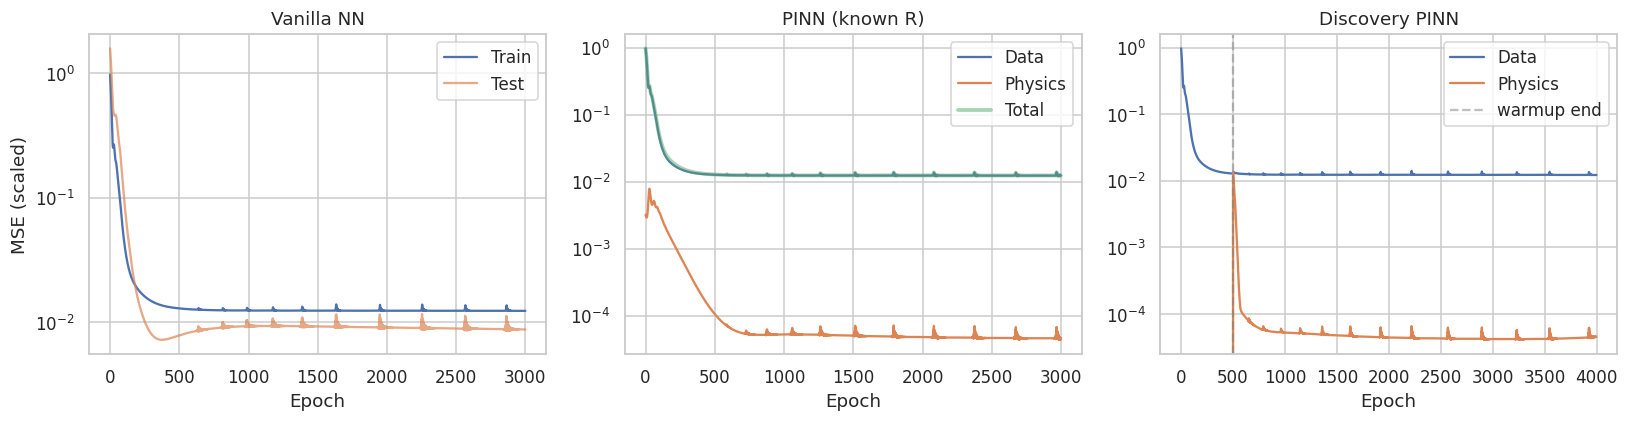

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses_v, label='Train')
axes[0].plot(test_losses_v, label='Test', alpha=0.7)
axes[0].set_yscale('log'); axes[0].set_title('Vanilla NN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (scaled)')
axes[0].legend()

axes[1].plot(train_data_losses_p, label='Data')
axes[1].plot(train_phys_losses_p, label='Physics')
axes[1].plot(train_total_p, label='Total', alpha=0.5, lw=2.5)
axes[1].set_yscale('log'); axes[1].set_title('PINN (known R)')
axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(train_data_losses_d, label='Data')
axes[2].plot(train_phys_losses_d, label='Physics')
axes[2].axvline(warmup_epochs, color='grey', ls='--', alpha=0.5, label='warmup end')
axes[2].set_yscale('log'); axes[2].set_title('Discovery PINN')
axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '06_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

### 10.2 R-value convergence (discovery)

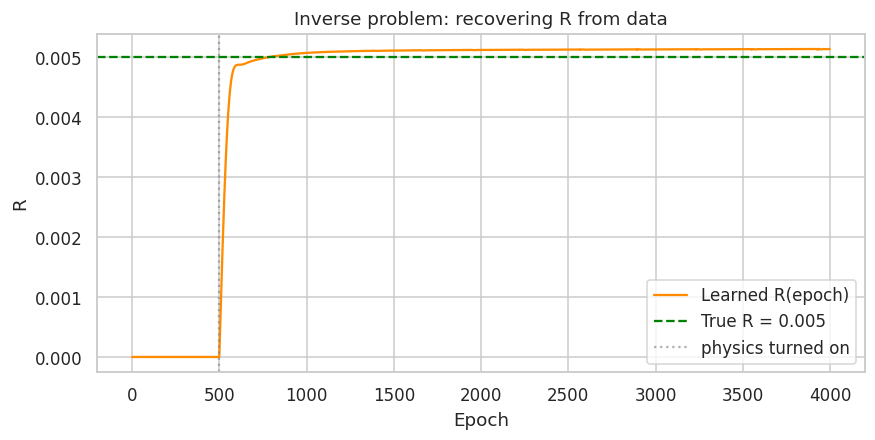

Final estimate: R = 0.005140  (true = 0.005)


In [16]:
plt.figure(figsize=(9, 4))
plt.plot(r_history, label='Learned R(epoch)', color='darkorange')
plt.axhline(R, color='green', ls='--', label=f'True R = {R}')
plt.axvline(warmup_epochs, color='grey', ls=':', alpha=0.6, label='physics turned on')
plt.xlabel('Epoch'); plt.ylabel('R'); plt.title('Inverse problem: recovering R from data')
plt.legend(); plt.savefig(os.path.join(PLOTS_DIR, '07_r_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Final estimate: R = {R_learned:.6f}  (true = {R})')

### 10.3 Curve fitting baselines (TRF / LM / polynomial)

In [17]:
# --- Curve fit on ORIGINAL units (not standardized) ---
xtr_raw = x_train.ravel(); ytr_raw = y_train.ravel()

def exp_model(t, Tenv_, T0_, R_):
    return Tenv_ + (T0_ - Tenv_) * np.exp(-R_ * t)

# TRF (Trust Region Reflective) -- works with bounds, robust
popt_trf, pcov_trf = curve_fit(
    exp_model, xtr_raw, ytr_raw, p0=[20., 90., 0.01], method='trf'
)

# LM (Levenberg-Marquardt) -- fast, no bounds
popt_lm, pcov_lm = curve_fit(
    exp_model, xtr_raw, ytr_raw, p0=[20., 90., 0.01], method='lm'
)

# Polynomial regression (no physics, pure fit)
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_model.fit(x_train_s, y_train)

print(f'TRF     -> Tenv={popt_trf[0]:7.3f}  T0={popt_trf[1]:7.3f}  R={popt_trf[2]:.6f}')
print(f'LM      -> Tenv={popt_lm[0]:7.3f}  T0={popt_lm[1]:7.3f}  R={popt_lm[2]:.6f}')
print(f'TRUE    -> Tenv={Tenv:7.3f}  T0={T0:7.3f}  R={R:.6f}')

TRF     -> Tenv= 24.923  T0=100.611  R=0.004946
LM      -> Tenv= 24.923  T0=100.611  R=0.004946
TRUE    -> Tenv= 25.000  T0=100.000  R=0.005000


### 10.4 Test-set MSEs (all models, same test set, physical units)

In [18]:
def nn_predict_celsius(net, x_scaled):
    net.eval()
    with torch.no_grad():
        ys = net(to_tensor(x_scaled)).cpu().numpy()
    return ys * sigma_T + mu_T

y_vanilla  = nn_predict_celsius(net_vanilla, x_test_s)
y_pinn     = nn_predict_celsius(net_pinn,    x_test_s)
y_disc     = nn_predict_celsius(net_disc,    x_test_s)
y_trf      = exp_model(x_test.ravel(), *popt_trf).reshape(-1, 1)
y_lm       = exp_model(x_test.ravel(), *popt_lm).reshape(-1, 1)
y_poly     = poly_model.predict(x_test_s).reshape(-1, 1)  # already in °C (fit on raw y_train)

def mse(y_pred, y_true):
    return float(np.mean((y_pred.ravel() - y_true.ravel()) ** 2))

results = {
    'Polynomial (deg 3)' : mse(y_poly,    y_test),
    'Vanilla NN'         : mse(y_vanilla, y_test),
    'PINN (known R)'     : mse(y_pinn,    y_test),
    'Discovery PINN'     : mse(y_disc,    y_test),
    'Curve fit — TRF'    : mse(y_trf,     y_test),
    'Curve fit — LM'     : mse(y_lm,      y_test),
}

print('Test MSE  (physical units, °C²)')
print('-' * 40)
for k, v in sorted(results.items(), key=lambda kv: kv[1]):
    print(f'  {k:<22s}  {v:8.4f}')

Test MSE  (physical units, °C²)
----------------------------------------
  Curve fit — TRF           2.2361
  Curve fit — LM            2.2361
  Discovery PINN            2.6574
  PINN (known R)            2.7108
  Vanilla NN                2.8220
  Polynomial (deg 3)        3.7226


## 11. Final Plots

Three views:

1. **Overlay** — every model's continuous prediction against the true solution.
2. **Scatter** — predicted vs. true for each model on the test set
   (points should sit on the diagonal if the model is good).
3. **Extrapolation experiment** — retrain vanilla NN and PINN on data restricted
   to $t \in [0, 500]$ only, then ask them to predict the full $[0, 1000]$ range.
   This is where the physics prior earns its keep: the vanilla NN has nothing
   telling it how the curve should behave past 500 s, but the PINN does.


### 11.1 Continuous curves overlay

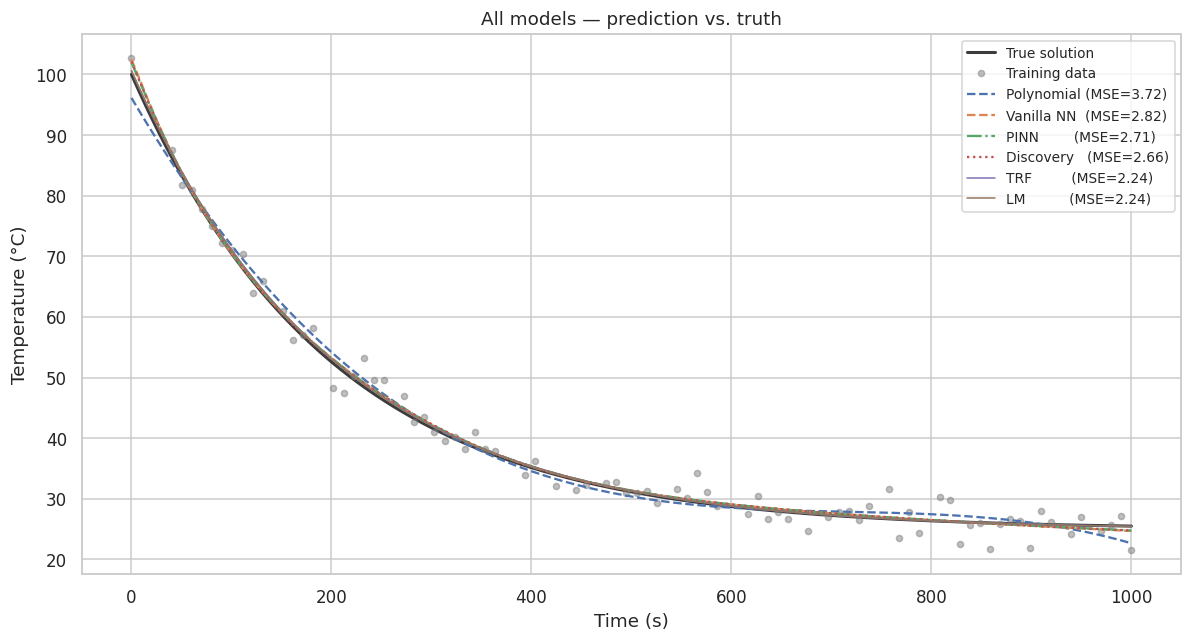

In [19]:
# Predict on the full dense grid
y_vanilla_full = nn_predict_celsius(net_vanilla, times_s)
y_pinn_full    = nn_predict_celsius(net_pinn,    times_s)
y_disc_full    = nn_predict_celsius(net_disc,    times_s)
y_poly_full    = poly_model.predict(times_s).reshape(-1, 1)  # already in °C
y_trf_full     = exp_model(times, *popt_trf)
y_lm_full      = exp_model(times, *popt_lm)

plt.figure(figsize=(11, 6))
plt.plot(times, temps, 'k-', lw=2, label='True solution', alpha=0.85)
plt.plot(x_train, y_train, 'o', color='grey', alpha=0.5, ms=4, label='Training data')

plt.plot(times, y_poly_full,    '--',  label=f'Polynomial (MSE={results["Polynomial (deg 3)"]:.2f})')
plt.plot(times, y_vanilla_full, '--',  label=f'Vanilla NN  (MSE={results["Vanilla NN"]:.2f})')
plt.plot(times, y_pinn_full,    '-.',  label=f'PINN        (MSE={results["PINN (known R)"]:.2f})')
plt.plot(times, y_disc_full,    ':',   label=f'Discovery   (MSE={results["Discovery PINN"]:.2f})')
plt.plot(times, y_trf_full,     lw=1,  label=f'TRF         (MSE={results["Curve fit — TRF"]:.2f})')
plt.plot(times, y_lm_full,      lw=1,  label=f'LM          (MSE={results["Curve fit — LM"]:.2f})')

plt.xlabel('Time (s)'); plt.ylabel('Temperature (°C)')
plt.title('All models — prediction vs. truth')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '08_overlay_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()

### 11.2 Scatter plots: predicted vs. actual (test set)

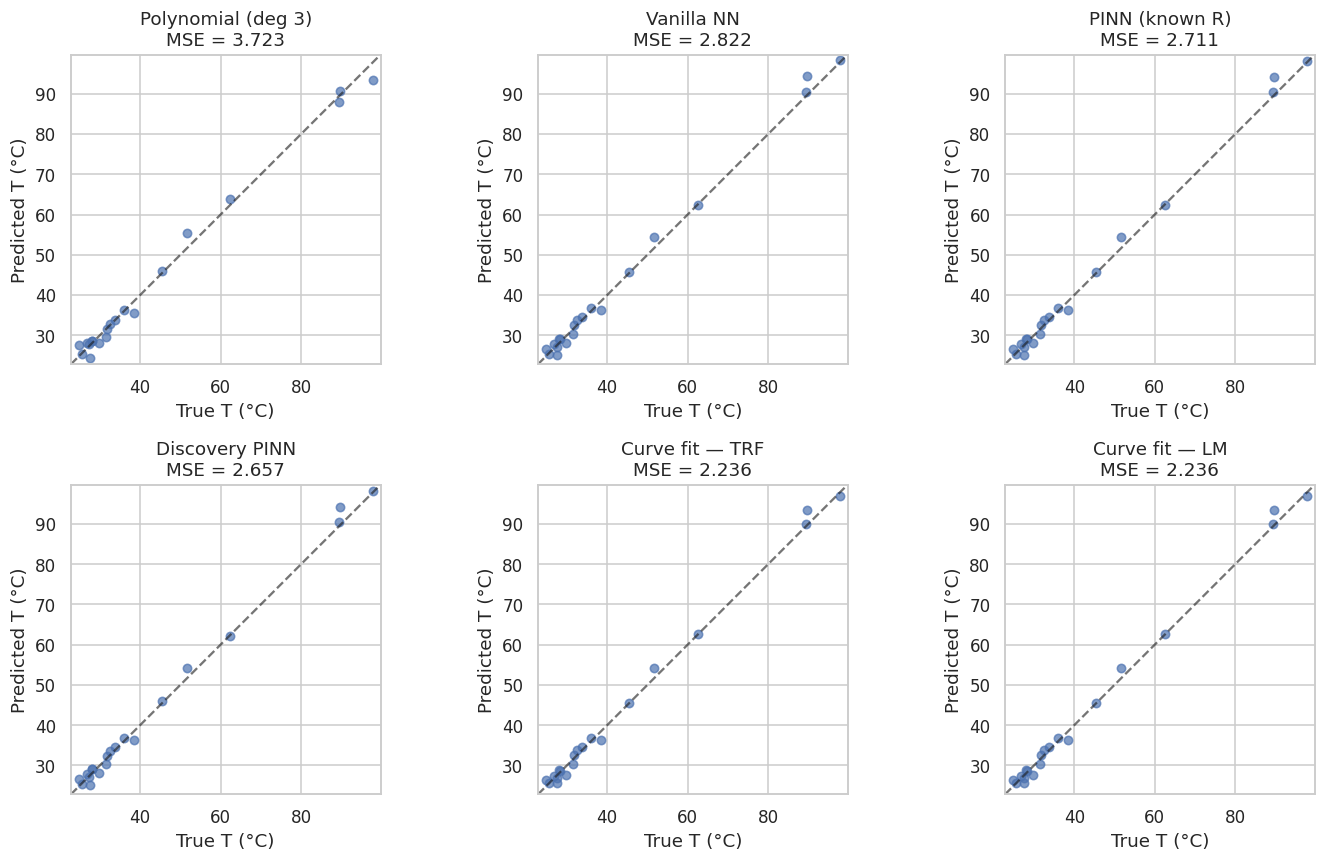

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
lo, hi = float(y_test.min()) - 2, float(y_test.max()) + 2

panels = [
    ('Polynomial (deg 3)', y_poly),
    ('Vanilla NN',         y_vanilla),
    ('PINN (known R)',     y_pinn),
    ('Discovery PINN',     y_disc),
    ('Curve fit — TRF',    y_trf),
    ('Curve fit — LM',     y_lm),
]

for ax, (name, y_pred) in zip(axes.ravel(), panels):
    ax.scatter(y_test, y_pred, alpha=0.7, s=30)
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.6, label='y = x')
    ax.set_xlabel('True T (°C)'); ax.set_ylabel('Predicted T (°C)')
    ax.set_title(f'{name}\nMSE = {results[name]:.3f}')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect('equal')

plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '09_scatter_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

### 11.3 Extrapolation — the actual selling point of PINNs

We take only the training points in the first half, $t \in [0, 500]$, and compare
vanilla NN vs. PINN at predicting the second half $[500, 1000]$ — a region with
**zero data** but fully covered by physics collocation points.


In [21]:
# Restrict training to t <= 500
mask = x_train.ravel() <= 500
xtr_half = x_train_s[mask]
ytr_half = y_train_s[mask]

xtr_half_t = to_tensor(xtr_half)
ytr_half_t = to_tensor(ytr_half)

print(f'Training points with t <= 500 s: {mask.sum()} / {len(x_train)}')

Training points with t <= 500 s: 39 / 80


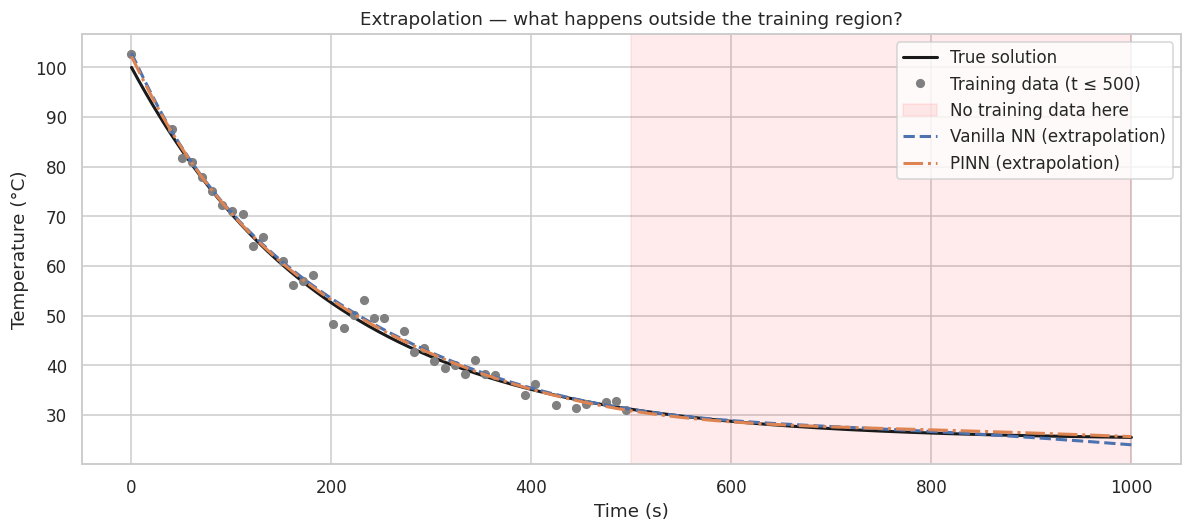

Extrapolation MSE vs. truth (t > 500 s):
  Vanilla NN  :    0.245
  PINN        :    0.190
  -> PINN is 1.3x better


In [22]:
# Retrain vanilla NN on reduced data
torch.manual_seed(42)
net_v_extrap = MLP().to(DEVICE)
opt = optim.Adam(net_v_extrap.parameters(), lr=learning_rate)
for ep in range(vanilla_epochs):
    opt.zero_grad()
    loss = loss_fn(net_v_extrap(xtr_half_t), ytr_half_t)
    loss.backward(); opt.step()

# Retrain PINN on reduced data (collocation still spans full [0, 1000])
torch.manual_seed(42)
net_p_extrap = MLP().to(DEVICE)
opt = optim.Adam(net_p_extrap.parameters(), lr=learning_rate)
for ep in range(pinn_epochs):
    opt.zero_grad()
    l_data = loss_fn(net_p_extrap(xtr_half_t), ytr_half_t)
    l_phys = physics_loss(net_p_extrap)
    loss = l_data + pinn_loss_weight * l_phys
    loss.backward(); opt.step()

y_v_extrap = nn_predict_celsius(net_v_extrap, times_s)
y_p_extrap = nn_predict_celsius(net_p_extrap, times_s)

plt.figure(figsize=(11, 5))
plt.plot(times, temps, 'k-', lw=2, label='True solution')
plt.plot(x_train[mask], y_train[mask], 'o', color='grey', ms=5,
         label='Training data (t ≤ 500)')
plt.axvspan(500, 1000, alpha=0.08, color='red', label='No training data here')
plt.plot(times, y_v_extrap, '--', lw=2, label='Vanilla NN (extrapolation)')
plt.plot(times, y_p_extrap, '-.', lw=2, label='PINN (extrapolation)')
plt.xlabel('Time (s)'); plt.ylabel('Temperature (°C)')
plt.title('Extrapolation — what happens outside the training region?')
plt.legend(); plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR, '10_extrapolation.png'), dpi=150, bbox_inches='tight')
plt.show()

# Quantify error in the extrapolation region
mask_extrap = (times >= 500)
mse_v_extrap = np.mean((y_v_extrap.ravel()[mask_extrap] - temps[mask_extrap])**2)
mse_p_extrap = np.mean((y_p_extrap.ravel()[mask_extrap] - temps[mask_extrap])**2)

print(f'Extrapolation MSE vs. truth (t > 500 s):')
print(f'  Vanilla NN  : {mse_v_extrap:8.3f}')
print(f'  PINN        : {mse_p_extrap:8.3f}')
print(f'  -> PINN is {mse_v_extrap / max(mse_p_extrap, 1e-9):.1f}x better')

### 11.4 Final summary table

| Method | Uses data? | Uses physics? | Works on new physics? | Extrapolates? |
|---|---|---|---|---|
| Polynomial | ✅ | ❌ | ❌ (just a basis) | ❌ |
| Vanilla NN | ✅ | ❌ | ❌ | ❌ |
| PINN (known $R$) | ✅ | ✅ | ✅ | ✅ |
| Discovery PINN | ✅ | ✅ | ✅ (learns $R$) | ✅ |
| Curve fit (TRF/LM) | ✅ | ✅ (exact form needed) | ❌ | ✅ within model |

**Key takeaways.**

- When the **exact ODE and its form are both known**, classical curve fitting is
  hard to beat — it has only 3 parameters vs. the NN's thousands, and it converges
  almost instantly. That's what the test-MSE table showed.
- **PINNs really start to matter** when (a) no closed-form solution exists,
  (b) data is sparse or missing in parts of the domain, or (c) the problem is inverse
  (unknown physical parameters to recover), or (d) the geometry is complex.
  The extrapolation experiment demonstrates (b); the discovery run demonstrates (c).
- For this concrete problem, PINNs are mostly a **validation tool** — useful
  precisely *because* we can check them against closed-form truth. That trust
  transfers to harder problems where curve fitting is no longer an option.
